<a href="https://colab.research.google.com/github/Bhadauriadevsingh007/Cinescope-/blob/main/CineScope.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:

from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

In [4]:
ratings = pd.read_csv("ratings.csv")
movies = pd.read_csv("movies.csv")

print(ratings.head())
print(movies.head())


   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  


In [5]:
df = pd.merge(ratings, movies, on="movieId")

print(df.head())


   userId  movieId  rating  timestamp                        title  \
0       1        1     4.0  964982703             Toy Story (1995)   
1       1        3     4.0  964981247      Grumpier Old Men (1995)   
2       1        6     4.0  964982224                  Heat (1995)   
3       1       47     5.0  964983815  Seven (a.k.a. Se7en) (1995)   
4       1       50     5.0  964982931   Usual Suspects, The (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                               Comedy|Romance  
2                        Action|Crime|Thriller  
3                             Mystery|Thriller  
4                       Crime|Mystery|Thriller  


In [6]:
df.drop_duplicates(inplace=True)

df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')

df.rename(columns={'genres': 'genre'}, inplace=True)


In [7]:
movie_views = df.groupby('movieId')['rating'].count()
df['views'] = df['movieId'].map(movie_views)


In [8]:
movie_likes = df.groupby('movieId')['rating'].mean()
df['likes'] = df['movieId'].map(movie_likes) * 100


In [9]:
df['popularity_score'] = (0.4 * df['views'] + 0.3 * df['likes'] + 0.3 * df['rating'])


In [10]:
df['month'] = df['timestamp'].dt.month


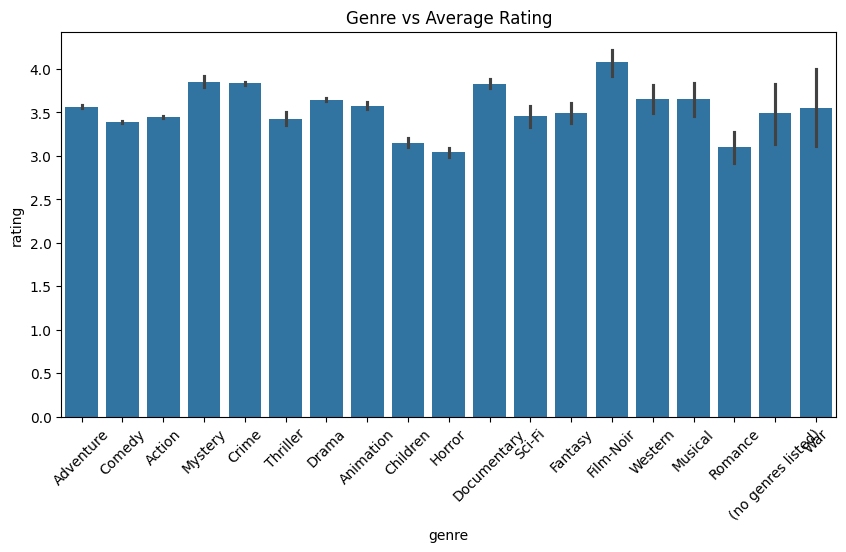

In [11]:
df['genre'] = df['genre'].apply(lambda x: x.split('|')[0])

plt.figure(figsize=(10,5))
sns.barplot(x='genre', y='rating', data=df)
plt.xticks(rotation=45)
plt.title("Genre vs Average Rating")
plt.show()


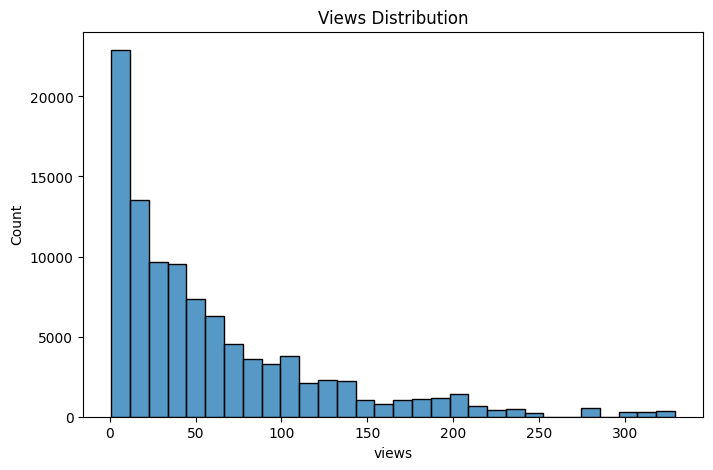

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['views'], bins=30)
plt.title("Views Distribution")
plt.show()


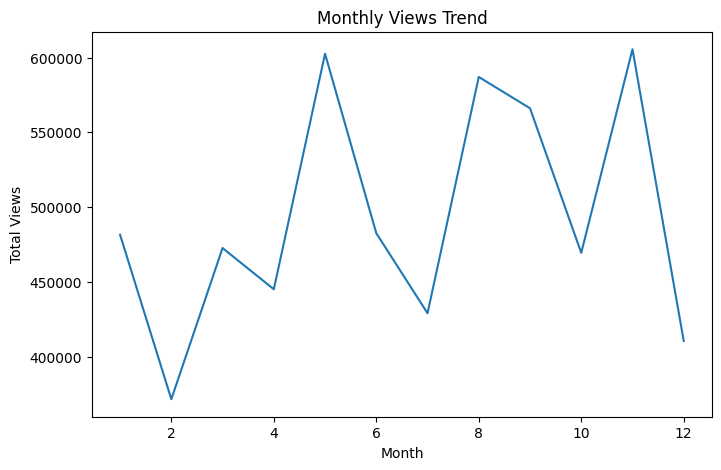

In [13]:
monthly_views = df.groupby('month')['views'].sum()

monthly_views.plot(figsize=(8,5))
plt.title("Monthly Views Trend")
plt.xlabel("Month")
plt.ylabel("Total Views")
plt.show()


In [14]:
X = df[['views','likes','rating']]
y = df['popularity_score']


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [16]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [17]:
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

X = df[['views','likes','rating']]
y = df['popularity_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))


R2 Score: 0.9999988333851525
MAE: 0.009704250343457512


In [18]:
user_movie_matrix = df.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
).fillna(0)


In [19]:
similarity = cosine_similarity(user_movie_matrix)

similarity_df = pd.DataFrame(
    similarity,
    index=user_movie_matrix.index,
    columns=user_movie_matrix.index
)


In [20]:
def recommend_movies(user_id, top_n=5):
    similar_users = similarity_df[user_id].sort_values(ascending=False)[1:6]
    similar_user_ids = similar_users.index

    recommended = user_movie_matrix.loc[similar_user_ids].mean().sort_values(ascending=False)

    return recommended.head(top_n)

print(recommend_movies(1))


movieId
1198    4.8
1200    4.8
2571    4.8
2028    4.7
296     4.5
dtype: float64


In [21]:
df.to_csv("final_entertainment_dataset.csv", index=False)


In [22]:
def search_movie(movie_name):
    result = df[df['title'].str.lower().str.contains(movie_name.lower())]

    if result.empty:
        return "Movie not found"

    return result[['title', 'genre']].drop_duplicates().head(5)

In [23]:
def get_movie_details(movie_name):
    movie = df[df['title'].str.lower().str.contains(movie_name.lower())]

    if movie.empty:
        return "Movie not found"

    movie_data = movie.iloc[0]

    return {
        "Title": movie_data['title'],
        "Genre": movie_data['genre'],
        "Average Rating": round(movie['rating'].mean(), 2),
        "Views": int(movie['views'].mean()),
        "Likes": round(movie['likes'].mean(), 2),
        "Popularity Score": round(movie['popularity_score'].mean(), 2)
    }

In [24]:
get_movie_details("Toy Story")

{'Title': 'Toy Story (1995)',
 'Genre': 'Adventure',
 'Average Rating': np.float64(3.93),
 'Views': 159,
 'Likes': np.float64(393.32),
 'Popularity Score': np.float64(183.11)}

In [25]:
get_movie_details("The Godfather")

{'Title': 'The Godfather Trilogy: 1972-1990 (1992)',
 'Genre': '(no genres listed)',
 'Average Rating': np.float64(4.75),
 'Views': 2,
 'Likes': np.float64(475.0),
 'Popularity Score': np.float64(144.73)}

In [26]:
get_movie_details("The Dark Knight")

{'Title': 'Batman: The Dark Knight Returns, Part 1 (2012)',
 'Genre': 'Action',
 'Average Rating': np.float64(3.9),
 'Views': 7,
 'Likes': np.float64(390.0),
 'Popularity Score': np.float64(121.18)}